In [ ]:
from wekeo.download import get_FRP_products
from wekeo.reader import read_FRP_product
import xarray as xr

from core import log as log
from core import env, save
from datetime import date
    
def get_log_event(day: date) -> xr.Dataset:
    """Download and Compile multiple FRP files into a single xarray Dataset."""
    
    log.info(f"Downloading FRP products for date: {day}")
    
    eday = day.strftime("%Y-%m-%d")
    sday = day.strftime("%Y-%m-%d") # same day for single day query

    files = get_FRP_products(
        start_date = sday,
        end_date = eday,
    )

    # Read specific variables
    variables = [
        'latitude', 
        'longitude',
        'FRP_SWIR',
        'FRP_uncertainty_SWIR',
        'FRP_MWIR', 
        'FRP_uncertainty_MWIR',
        'confidence_SWIR_SAA',  # SAA flag for quality control
        'solar_zenith',
        # 'S8_Fire_pixel_BT',  # This is from a different dimension
    ]
    
    log.info(f"Compiling {len(files)} FRP products into a Log Event dataset")
    datasets = []
    
    for f in files:
        ds = read_FRP_product(f, variables=variables).compute()
        datasets.append(ds)
        
    log_event = xr.concat(datasets, dim='merged_MWIR1kmStandard_SWIR1km')
    log_event = log_event.rename_dims({"merged_MWIR1kmStandard_SWIR1km": "nb_detection"})
    log_event = log_event.rename_vars({"solar_zenith": "sza"})
    
    return log_event

day = date(2022, 7, 15)
log_event = get_log_event(day)
sday = day.strftime("%Y_%m_%d")
print(log_event)

output_dir = env.getdir("OUTPUT_DIR")
save.to_netcdf(log_event, f"{output_dir}/log_event_{sday}.nc", if_exists="overwrite")


In [ ]:
import xarray as xr

f = "/mnt/ceph/proj/IASI_PCA3/PROD_TEST/METOP-C_IASI_PCA3-LogEvent-L1a.v1.00/2024/2024_07_15/METOP-C_IASI_PCA3-LogEvent-L1a_2024-07-15_V1-00.nc"
ds = xr.open_dataset(f)

# print(ds)
for d in ds.data_vars:
    print(d)

In [ ]:
f = "/mnt/ceph/proj/WEKEO/outputs/log_event_2022_07_15.nc"
log_event = xr.open_dataset(f)

for v in log_event.data_vars:
    print(v)
    
pass

(<Figure size 1600x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Frp Swir Count\n(1104 non-zero pixels, 1104 valid pixels)'}>)

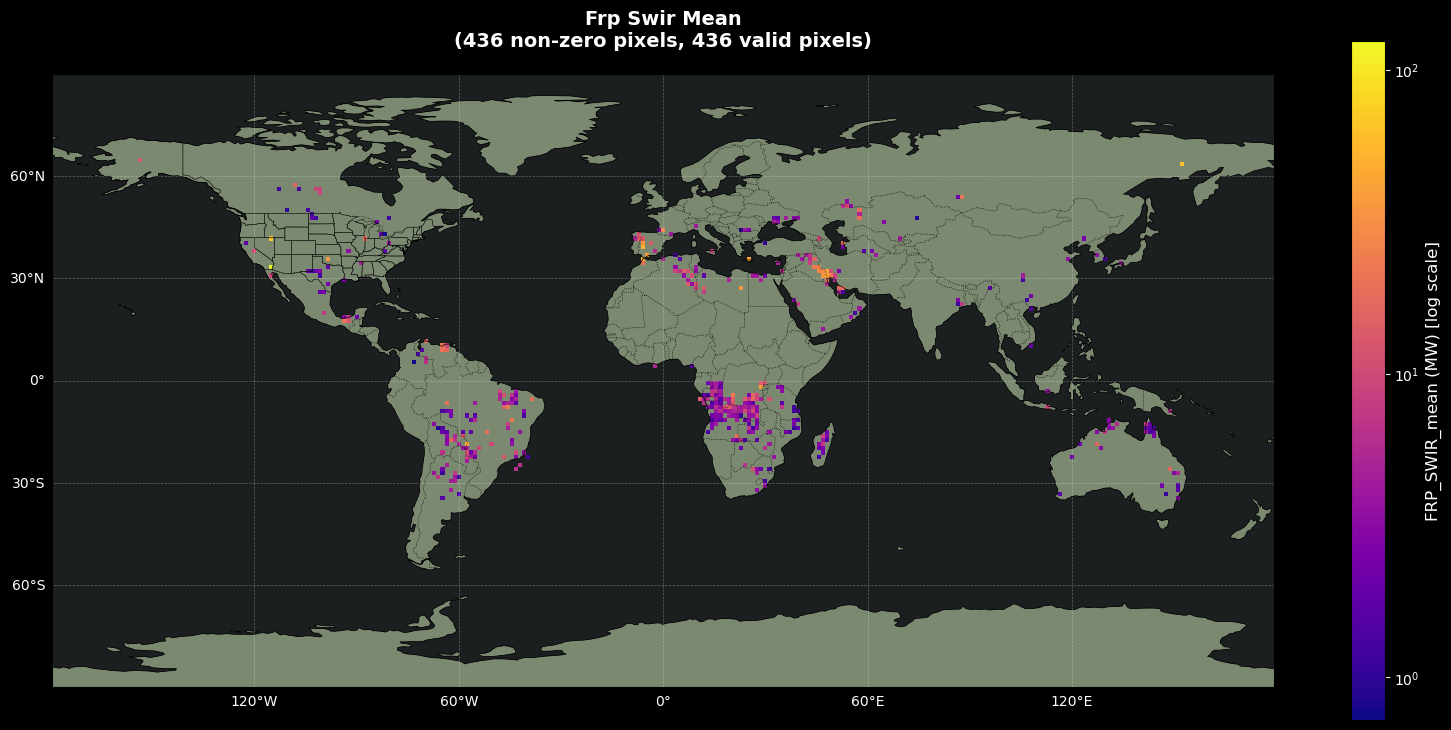

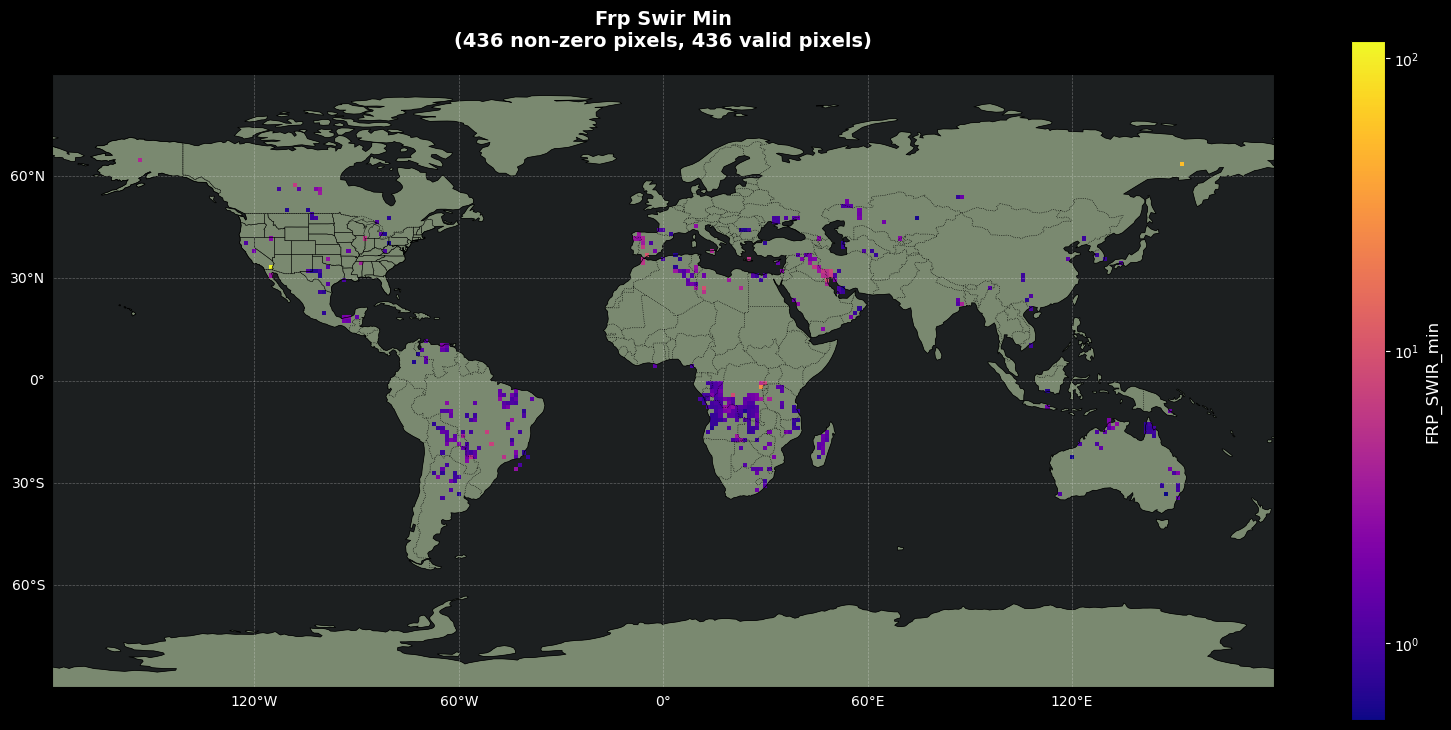

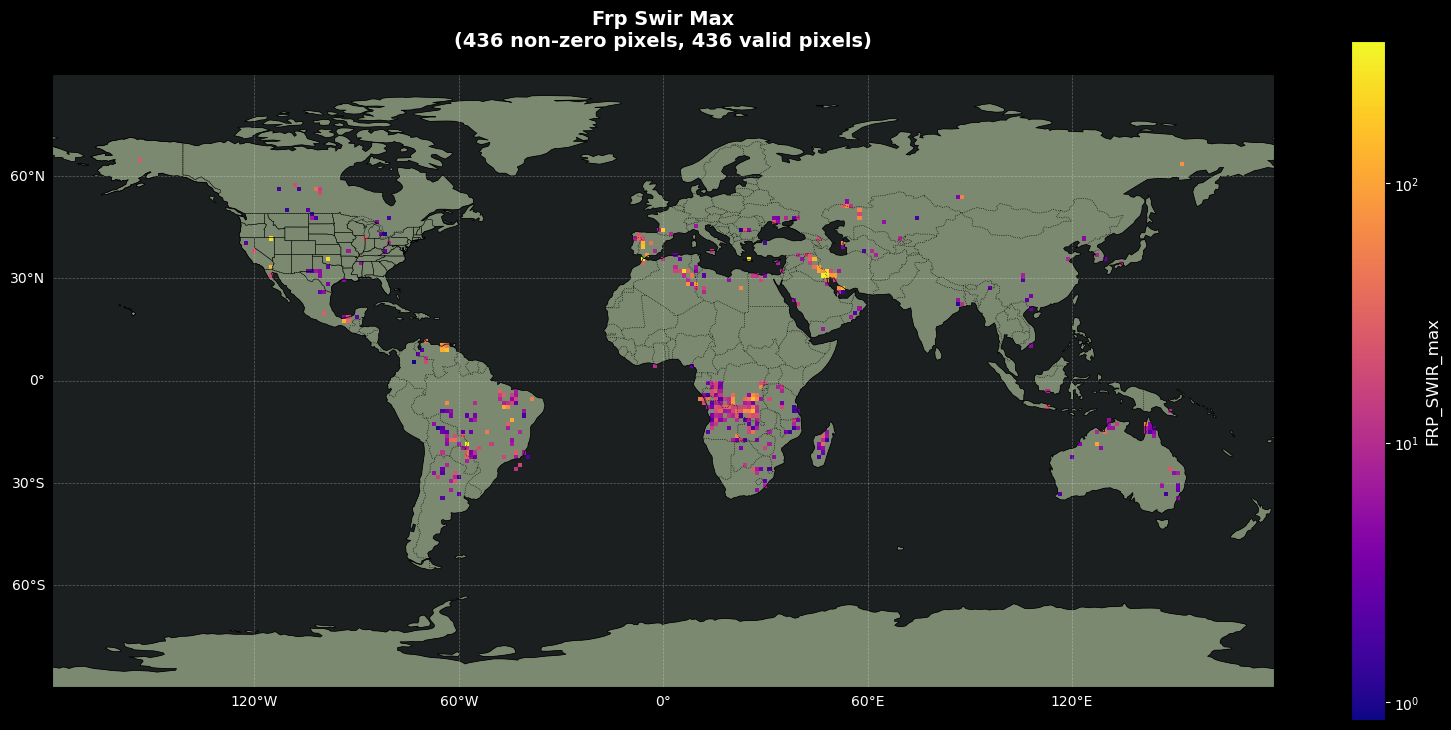

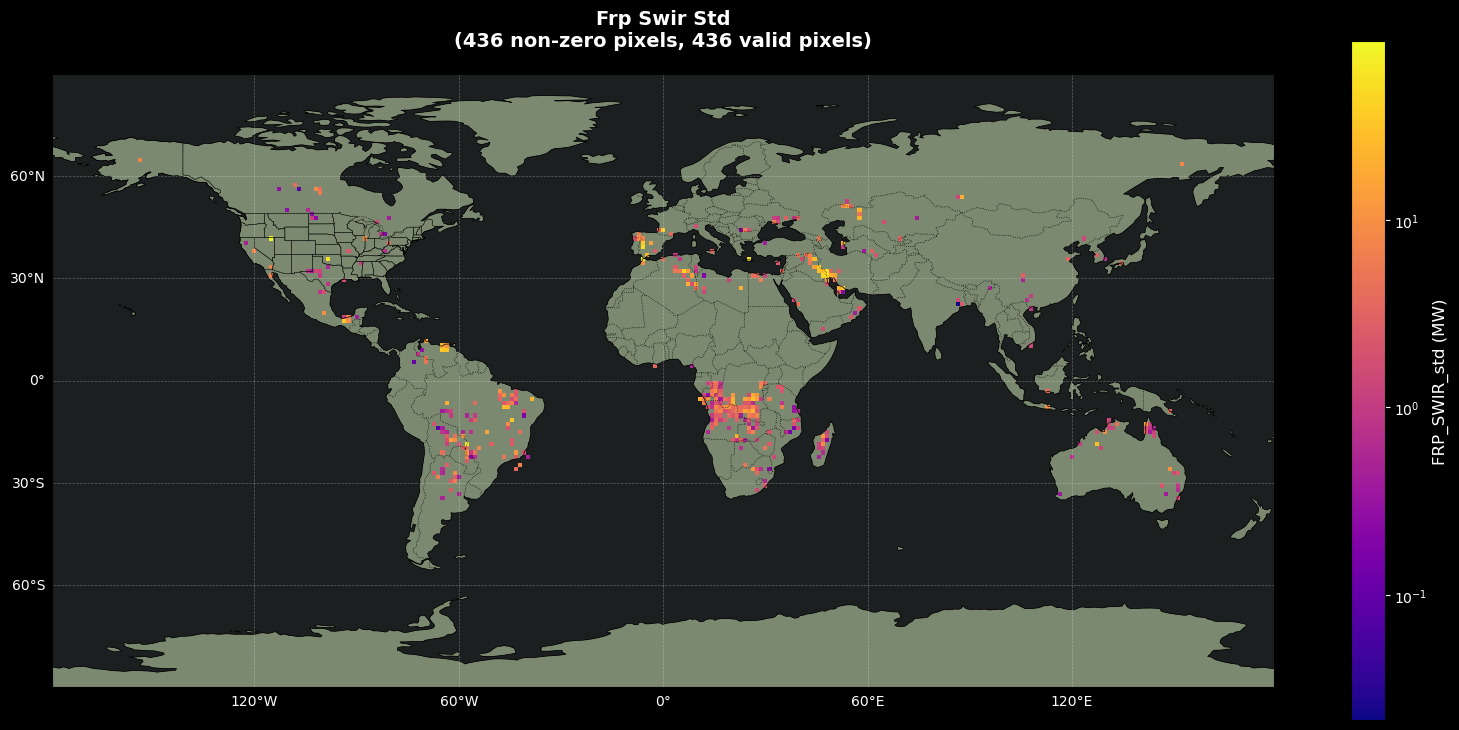

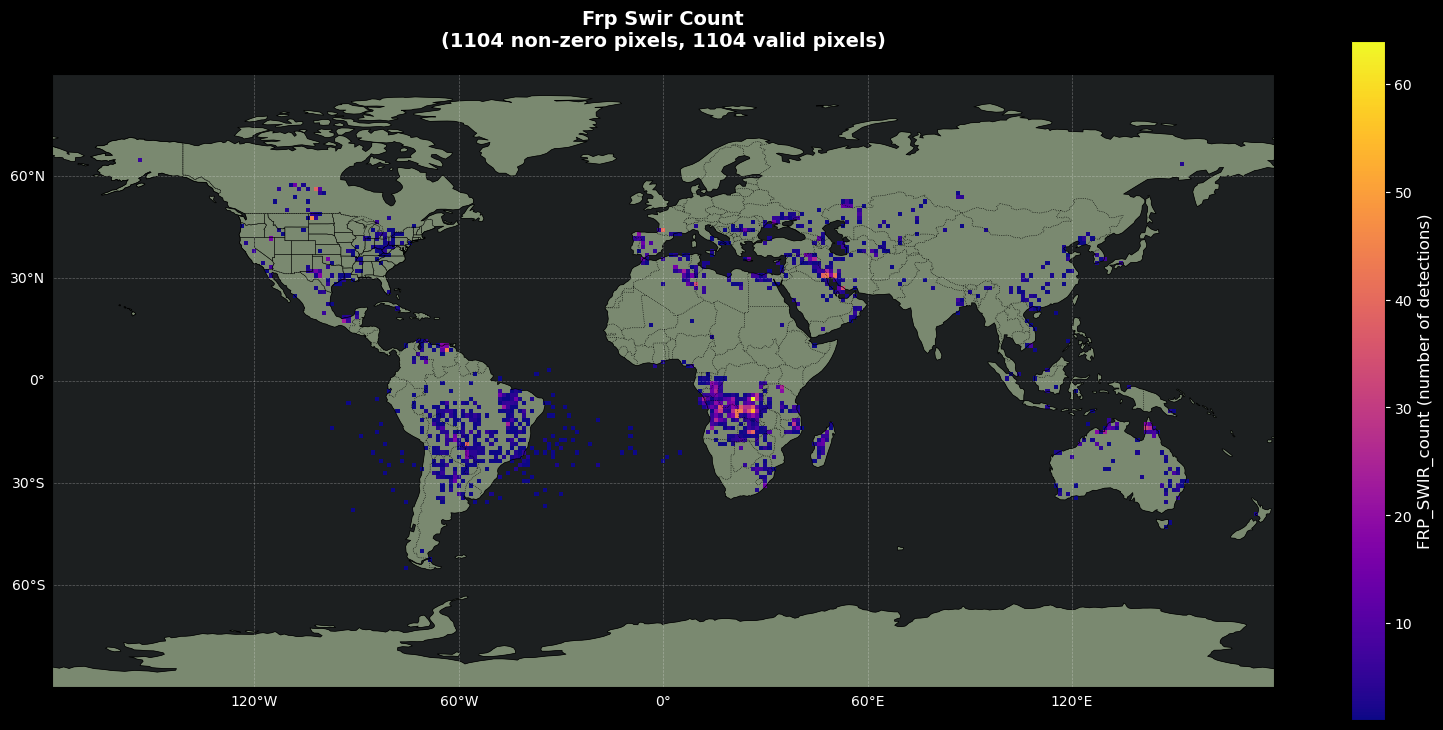

In [ ]:
from wekeo.log_event_accumulator import accumulate_events_to_grid

import xarray as xr

f = "/mnt/ceph/proj/WEKEO/outputs/log_event_2022_07_15.nc"
log_event = xr.open_dataset(f)

# print(log_event)

l3 = accumulate_events_to_grid(
    log_event,
    width=300,
    min_count=3,
)


from wekeo.plot_L3_FRP import plot_L3_FRP
import numpy as np

colormap = "plasma"

# Single variable
plot_L3_FRP(l3, variable='FRP_SWIR_mean', cmap=colormap)
plot_L3_FRP(l3, variable='FRP_SWIR_min', cmap=colormap)
plot_L3_FRP(l3, variable='FRP_SWIR_max', cmap=colormap)
plot_L3_FRP(l3, variable='FRP_SWIR_std', cmap=colormap)
plot_L3_FRP(l3, variable='FRP_SWIR_count', cmap='autumn')


# print(np.nanmean(l3.FRP_SWIR_min.values))

# plot_L3_FRP(l3, variable='FRP_SWIR_min')
# plot_L3_FRP(l3, variable='FRP_SWIR_max')
# plot_L3_FRP(l3, variable='FRP_SWIR_count')



# plot_L3_FRP(l3, variable='FRP_SWIR_no_SAA_mean')
# plot_L3_FRP(l3, variable='FRP_MWIR_mean')
